# MCal Training Dynamics: Sample Size Study

Train MCal_CE_Uncond with different sample sizes on binomial-ablated data (p=0.5).

## Methodology (Matching KL Benchmarks):

1. **Base Models**: Use vanilla models trained on clean data only
   - MRI: ViT trained on clean images (no augmentation with missing patches)
   - MedQA: LLaMA-3-8B (standard pretrained model)
   - PhysioNet: XGBoost trained on clean data with mean imputation

2. **Ablation Strategy**: Binomial with p=0.5
   - Each feature (patch/token/attribute) dropped independently with probability 0.5
   - This creates diverse ablation patterns for robust training

3. **MCal Training**: Unconditional calibration
   - Learn to map: ablated predictions → clean predictions
   - No class conditioning (simpler, more general approach)

4. **Evaluation**: Missingness Bias
   - Measure KL divergence between class distributions
   - Compare ablated vs clean (baseline) and calibrated vs clean (with MCal)

5. **Key Difference from Prior Work**:
   - PhysioNet: Using zero-filling for predictions (not mean imputation) to maintain clear distinction
   - This prevents imputation from masking the ablation effects

**Datasets**: MRI (vision), MedQA (language), PhysioNet (tabular)

**Sample sizes**: [5, 10, 25, 50, 100, 250, 500, 1000, 2000, 2500, 5000]

In [1]:
import sys
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
import json

# Setup paths
current_dir = Path('.').absolute()
mcal_root = current_dir.parent if current_dir.name == 'experiments' else current_dir
sys.path.insert(0, str(mcal_root))
sys.path.insert(0, str(mcal_root / 'src'))
sys.path.insert(0, str(mcal_root / 'experiments'))

from src.calibrators.mcal_ce import MCal_CE
from experiment_utils import missingness_bias  # Import missingness bias function

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"MCal root: {mcal_root}")
print(f"Device: {device}")

MCal root: /ssd1/ayx98/MCal
Device: cuda:0


## Helper Functions

In [2]:
def generate_mri_data(split='test', n_samples=2000):
    """
    Load clean MRI images and generate predictions with vanilla model.
    Apply binomial ablations (p=0.5 per patch) for MCal training.
    """
    print(f"Generating MRI data (split={split}, n={n_samples})...")
    import timm
    from all_data_loaders import load_mri_clean_and_ablated
    
    # Load clean and ablated images with p=0.5 binomial ablations
    # Each patch is independently dropped with probability 0.5
    images_clean, images_ablated, labels = load_mri_clean_and_ablated(
        split=split, p_ablate=0.5, n_samples=n_samples, seed=42, shuffle=True
    )
    
    # Load VANILLA model (trained on clean data only) - matching KL benchmark
    model_path = mcal_root / 'saved_models' / 'vit_timm_standard_mri_ps64_35e.pth'
    
    if not model_path.exists():
        # Fallback to ablate=0.00 model if standard model doesn't exist
        model_path = mcal_root / 'saved_models' / 'mri' / 'vit_mri_ps32_ablate0.00_best.pth'
        print(f"  Using ablate=0.00 model: {model_path}")
    else:
        print(f"  Using standard vanilla model: {model_path}")
    
    # Create model and load weights
    model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=4)
    
    # Load state dict - handle both checkpoint and direct state dict formats
    state_dict = torch.load(model_path, map_location=device)
    if 'model_state_dict' in state_dict:
        model.load_state_dict(state_dict['model_state_dict'])
    else:
        model.load_state_dict(state_dict)
    
    model.to(device).eval()
    
    # Generate predictions using vanilla model
    with torch.no_grad():
        # Clean predictions (no ablation)
        probs_clean = F.softmax(model(images_clean.to(device)), dim=1).cpu().numpy()
        # Ablated predictions (p=0.5 binomial ablation per patch)
        probs_ablated = F.softmax(model(images_ablated.to(device)), dim=1).cpu().numpy()
    
    print(f"  Clean: {probs_clean.shape}, Ablated: {probs_ablated.shape}")
    return probs_clean, probs_ablated, labels.numpy()


def generate_medqa_data(split='test', n_samples=2000):
    """
    Load clean MedQA and generate predictions with vanilla LLaMA.
    Apply binomial ablations (p=0.5 per token) for MCal training.
    """
    print(f"Generating MedQA data (split={split}, n={n_samples})...")
    from all_data_loaders import load_medqa_clean_and_ablated
    from transformers import AutoTokenizer, AutoModelForCausalLM
    
    # Load clean and ablated datasets with p=0.5 binomial ablations
    # Each token is independently dropped with probability 0.5
    dataset_clean, dataset_ablated = load_medqa_clean_and_ablated(
        split=split, p_ablate=0.5, n_samples=n_samples, seed=42, shuffle=True
    )
    
    # Load vanilla model (no special training for robustness)
    model_path = mcal_root / 'saved_models' / 'language' / 'Meta-Llama-3-8B-Instruct'
    print(f"  Loading LLaMA...")
    tokenizer = AutoTokenizer.from_pretrained(str(model_path))
    model = AutoModelForCausalLM.from_pretrained(str(model_path), torch_dtype=torch.float16, device_map=device)
    model.eval()
    
    answer_tokens = [tokenizer.encode(l, add_special_tokens=False)[0] for l in ['A', 'B', 'C', 'D', 'E']]
    probs_clean, probs_ablated, labels = [], [], []
    
    for item_clean, item_ablated in tqdm(zip(dataset_clean, dataset_ablated), total=len(dataset_clean)):
        options_text = "\n".join([f"{opt['key']}. {opt['value']}" for opt in item_clean['options']])
        
        # Clean predictions
        prompt = f"Question: {item_clean['question']}\n\nOptions:\n{options_text}\nAnswer: "
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        with torch.no_grad():
            logits = model(**inputs).logits[0, -1, answer_tokens]
        probs_clean.append(F.softmax(logits, dim=0).cpu().numpy())
        
        # Ablated predictions (with p=0.5 token dropping)
        prompt = f"Question: {item_ablated['question']}\n\nOptions:\n{options_text}\nAnswer: "
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        with torch.no_grad():
            logits = model(**inputs).logits[0, -1, answer_tokens]
        probs_ablated.append(F.softmax(logits, dim=0).cpu().numpy())
        
        labels.append(ord(item_clean['answer_idx']) - ord('A'))
    
    probs_clean = np.array(probs_clean)
    probs_ablated = np.array(probs_ablated)
    labels = np.array(labels)
    print(f"  Clean: {probs_clean.shape}, Ablated: {probs_ablated.shape}")
    return probs_clean, probs_ablated, labels


# Global XGBoost model for PhysioNet (train once, use for all splits)
_physionet_model = None

def generate_physionet_data(split='test', n_samples=1000):
    """
    Load clean PhysioNet and generate predictions following kl_physionet approach.
    Uses vanilla model trained on clean data with mean imputation.
    Applies binomial ablations (p=0.5 per feature) and zero-filling for test.
    """
    global _physionet_model
    
    print(f"Generating PhysioNet data (split={split}, n={n_samples})...")
    from all_data_loaders import load_physionet_clean_and_ablated
    from sklearn.impute import SimpleImputer
    import xgboost as xgb
    
    # Train vanilla model once on CLEAN training data (matching kl_physionet)
    if _physionet_model is None:
        print("  Training XGBoost on CLEAN training data with mean imputation...")
        from all_data_loaders import load_physionet_clean
        X_train_full, y_train_full = load_physionet_clean(split='train', n_samples=None)
        
        # Mean imputation for training (matching kl_physionet vanilla model)
        imputer = SimpleImputer(strategy='mean')
        X_train_imputed = imputer.fit_transform(X_train_full)
        
        # Train vanilla XGBoost model
        _physionet_model = xgb.XGBClassifier(
            objective='binary:logistic', 
            eval_metric='logloss',
            eta=0.1, 
            max_depth=6, 
            seed=42, 
            tree_method='hist'
        )
        _physionet_model.fit(X_train_imputed, y_train_full)
        print(f"  Trained vanilla model on {len(X_train_full)} clean samples")
    
    # Load clean and ablated data for the requested split
    # Binomial ablation: each feature has p=0.5 chance of being dropped
    X_clean, X_ablated, y = load_physionet_clean_and_ablated(
        split=split, p_ablate=0.5, n_samples=n_samples, seed=42, shuffle=True
    )
    
    # For predictions: use ZERO-filling for ablated features (matching common kl_physionet approach)
    # This creates a clear distinction between clean and ablated
    # Clean data: use as-is (may have natural missingness, fill with 0)
    X_clean_filled = np.nan_to_num(X_clean, nan=0.0)
    # Ablated data: already has additional missingness, fill with 0
    X_ablated_filled = np.nan_to_num(X_ablated, nan=0.0)
    
    # Generate predictions
    probs_clean = _physionet_model.predict_proba(X_clean_filled)
    probs_ablated = _physionet_model.predict_proba(X_ablated_filled)
    
    print(f"  Clean: {probs_clean.shape}, Ablated: {probs_ablated.shape}")
    print(f"  Using zero-filling for missing values during prediction")
    return probs_clean, probs_ablated, y

In [3]:
import time

def train_and_eval_mcal(probs_clean_train, probs_ablated_train,
                         probs_clean_test, probs_ablated_test,
                         n_samples, max_steps=5000):
    """
    Train MCal on n training samples, evaluate on test set.
    
    Training approach (matching KL benchmarks):
    - Train MCal to map ablated predictions → clean predictions
    - Ablations are binomial with p=0.5 (each feature dropped independently)
    - This is UNCONDITIONAL MCal (no class conditioning)
    
    Evaluation:
    - Missingness bias measured as KL divergence between class distributions
    - Compare: ablated vs clean (baseline) and calibrated vs clean (with MCal)
    """
    # Subsample training data
    probs_clean_sub = torch.tensor(probs_clean_train[:n_samples], dtype=torch.float32, device=device)
    probs_ablated_sub = torch.tensor(probs_ablated_train[:n_samples], dtype=torch.float32, device=device)
    
    # Target labels from clean predictions (MCal learns to predict clean from ablated)
    target_labels = probs_clean_sub.argmax(dim=-1)
    
    # Train UNCONDITIONAL MCal calibrator
    calibrator = MCal_CE(num_classes=probs_clean_train.shape[1], head_type="linear")
    calibrator.to(device)
    
    # Time the training
    start_time = time.time()
    stats = calibrator.fit(
        ablated_probs=probs_ablated_sub,
        target_labels=target_labels,
        max_steps=max_steps,
        lr=1e-3,
        verbose=False
    )
    training_time = time.time() - start_time
    
    # Evaluate on test set
    probs_clean_test_t = torch.tensor(probs_clean_test, dtype=torch.float32, device=device)
    probs_ablated_test_t = torch.tensor(probs_ablated_test, dtype=torch.float32, device=device)
    
    with torch.no_grad():
        # Apply MCal calibration to ablated test predictions
        calibrated_test = calibrator(probs_ablated_test_t)
        
        # Accuracy: how well does calibrated match clean predictions
        test_preds = calibrated_test.argmax(dim=-1)
        test_targets = probs_clean_test_t.argmax(dim=-1)
        test_acc = (test_preds == test_targets).float().mean().item()
        
        # Compute missingness bias WITHOUT calibration (baseline)
        # MissingnessBias(f) = KL( E[Class(f(x'))] || E[Class(f(x))] )
        # where f(x') is ablated and f(x) is clean
        uncalibrated_bias = missingness_bias(probs_ablated_test_t, probs_clean_test_t).item()
        
        # Compute missingness bias WITH calibration
        # Now comparing calibrated predictions to clean
        calibrated_bias = missingness_bias(calibrated_test, probs_clean_test_t).item()
    
    stats['test_acc'] = test_acc
    stats['training_time'] = training_time
    stats['missingness_bias_uncal'] = uncalibrated_bias
    stats['missingness_bias_cal'] = calibrated_bias
    stats['missingness_bias_reduction'] = (uncalibrated_bias - calibrated_bias) / uncalibrated_bias * 100 if uncalibrated_bias > 0 else 0
    
    return stats

## Run Experiments

In [4]:
sample_sizes = [5, 10, 25, 50, 100, 250, 500, 1000, 2500, 5000]
max_steps = 5000

# Set to True to rerun all experiments even if saved results exist
FORCE_RERUN = False

# Try to load existing results
results_file = mcal_root / 'results' / 'mcal_training_dynamics.json'
results = {}

if not FORCE_RERUN and results_file.exists():
    with open(results_file, 'r') as f:
        results = json.load(f)
    # JSON keys are strings, convert back to int
    for dataset in list(results.keys()):
        results[dataset] = {int(k): v for k, v in results[dataset].items()}
    print(f"Loaded existing results from: {results_file}")
    print(f"  Datasets: {list(results.keys())}")
    for ds, ds_results in results.items():
        print(f"  {ds}: sample sizes {sorted(ds_results.keys())}")
    print(f"\nSet FORCE_RERUN = True to recompute everything.")
else:
    if FORCE_RERUN:
        print("FORCE_RERUN is True — will recompute all experiments.")
    else:
        print(f"No saved results found at {results_file} — will compute from scratch.")

Loaded existing results from: /ssd1/ayx98/MCal/results/mcal_training_dynamics.json
  Datasets: ['mri', 'medqa', 'physionet']
  mri: sample sizes [5, 10, 25, 50, 100, 250, 500, 1000, 2500, 5000]
  medqa: sample sizes [5, 10, 25, 50, 100, 250, 500, 1000, 2500, 5000]
  physionet: sample sizes [5, 10, 25, 50, 100, 250, 500, 840]

Set FORCE_RERUN = True to recompute everything.


In [5]:
if 'mri' not in results:
    # MRI
    print("=" * 60)
    print("MRI EXPERIMENT")
    print("=" * 60)

    # Load ALL available train and test data (don't cap training data)
    probs_clean_train, probs_ablated_train, labels_train = generate_mri_data(split='train', n_samples=None)
    probs_clean_test, probs_ablated_test, labels_test = generate_mri_data(split='test', n_samples=None)

    print(f"Train set: {len(probs_clean_train)} samples")
    print(f"Test set: {len(probs_clean_test)} samples")

    results['mri'] = {}

    for n in sample_sizes:
        if n > len(probs_clean_train):
            print(f"\nSkipping n={n} (exceeds training data size)")
            continue
        print(f"\nTraining n={n}...")
        stats = train_and_eval_mcal(probs_clean_train, probs_ablated_train,
                                     probs_clean_test, probs_ablated_test,
                                     n, max_steps)
        results['mri'][n] = stats
        print(f"  Train loss: {stats['loss'][-1]:.6f}, Train acc: {stats['acc'][-1]:.4f}, Test acc: {stats['test_acc']:.4f}")
        print(f"  Missingness bias - Uncal: {stats['missingness_bias_uncal']:.4f}, Cal: {stats['missingness_bias_cal']:.4f}, Reduction: {stats['missingness_bias_reduction']:.1f}%")

    print("\n✅ MRI complete")
else:
    print("✅ MRI results already loaded, skipping computation.")

✅ MRI results already loaded, skipping computation.


In [6]:
if 'medqa' not in results:
    # MedQA
    print("=" * 60)
    print("MEDQA EXPERIMENT")
    print("=" * 60)

    # Load train and test data with enough samples
    probs_clean_train, probs_ablated_train, labels_train = generate_medqa_data(split='train', n_samples=5000)
    probs_clean_test, probs_ablated_test, labels_test = generate_medqa_data(split='test', n_samples=None)

    print(f"Train set: {len(probs_clean_train)} samples")
    print(f"Test set: {len(probs_clean_test)} samples")

    results['medqa'] = {}

    for n in sample_sizes:
        if n > len(probs_clean_train):
            print(f"\nSkipping n={n} (exceeds training data size)")
            continue
        print(f"\nTraining n={n}...")
        stats = train_and_eval_mcal(probs_clean_train, probs_ablated_train,
                                     probs_clean_test, probs_ablated_test,
                                     n, max_steps)
        results['medqa'][n] = stats
        print(f"  Train loss: {stats['loss'][-1]:.6f}, Train acc: {stats['acc'][-1]:.4f}, Test acc: {stats['test_acc']:.4f}")
        print(f"  Missingness bias - Uncal: {stats['missingness_bias_uncal']:.4f}, Cal: {stats['missingness_bias_cal']:.4f}, Reduction: {stats['missingness_bias_reduction']:.1f}%")

    print("\n✅ MedQA complete")
else:
    print("✅ MedQA results already loaded, skipping computation.")

✅ MedQA results already loaded, skipping computation.


In [7]:
if 'physionet' not in results:
    # PhysioNet
    print("=" * 60)
    print("PHYSIONET EXPERIMENT")
    print("=" * 60)

    # Load train and test data with enough samples
    probs_clean_train, probs_ablated_train, labels_train = generate_physionet_data(split='train', n_samples=None)
    probs_clean_test, probs_ablated_test, labels_test = generate_physionet_data(split='test', n_samples=None)

    print(f"Train set: {len(probs_clean_train)} samples")
    print(f"Test set: {len(probs_clean_test)} samples")

    results['physionet'] = {}

    # PhysioNet only has 840 training samples, so add that to the sample sizes
    physionet_sample_sizes = [n for n in sample_sizes if n <= len(probs_clean_train)]
    # Add 840 if not already present and it fits
    if 840 not in physionet_sample_sizes and 840 <= len(probs_clean_train):
        physionet_sample_sizes.append(840)
        physionet_sample_sizes.sort()

    print(f"Sample sizes for PhysioNet: {physionet_sample_sizes}")

    for n in physionet_sample_sizes:
        print(f"\nTraining n={n}...")
        stats = train_and_eval_mcal(probs_clean_train, probs_ablated_train,
                                     probs_clean_test, probs_ablated_test,
                                     n, max_steps)
        results['physionet'][n] = stats
        print(f"  Train loss: {stats['loss'][-1]:.6f}, Train acc: {stats['acc'][-1]:.4f}, Test acc: {stats['test_acc']:.4f}")
        print(f"  Missingness bias - Uncal: {stats['missingness_bias_uncal']:.4f}, Cal: {stats['missingness_bias_cal']:.4f}, Reduction: {stats['missingness_bias_reduction']:.1f}%")

    print("\n✅ PhysioNet complete")
else:
    print("✅ PhysioNet results already loaded, skipping computation.")

✅ PhysioNet results already loaded, skipping computation.


## Visualization

In [8]:
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'cm'

# Shared style constants (matching other MCal figures)
LABEL_FONTSIZE = 14
TICK_LABELSIZE = 12
LEGEND_FONTSIZE = 10
LINEWIDTH = 2.0
GRID_ALPHA = 0.2
TIGHT_PAD = 0.5

fig_width = 3.25
fig_height = 2.4

def plot_training_curves(results_dict, display_name, metric='loss'):
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    
    for n in sorted(results_dict.keys()):
        stats = results_dict[n]
        ax.plot(stats[metric], label=f'n={n}', alpha=0.8, linewidth=1.5)
    
    ax.set_xlabel(f'{display_name} Train Steps', fontsize=LABEL_FONTSIZE)
    ax.set_ylabel('Loss' if metric == 'loss' else 'Accuracy', fontsize=LABEL_FONTSIZE)
    ax.legend(fontsize=8, loc='best')
    ax.tick_params(axis='both', which='major', labelsize=TICK_LABELSIZE)
    ax.grid(alpha=GRID_ALPHA)
    if metric == 'loss':
        ax.set_yscale('log')
    
    plt.tight_layout(pad=TIGHT_PAD)
    return fig

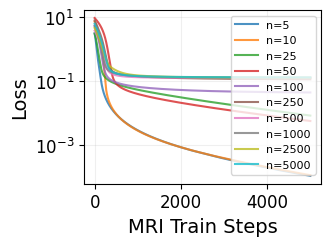

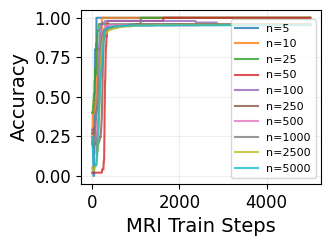

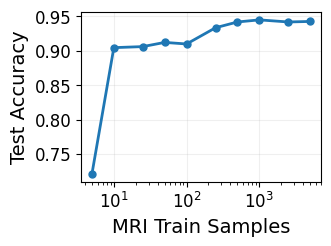

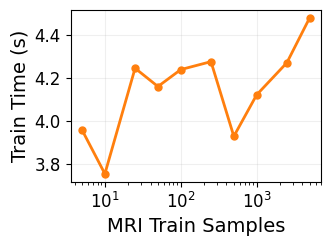

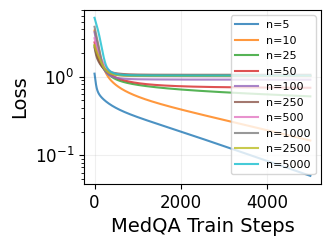

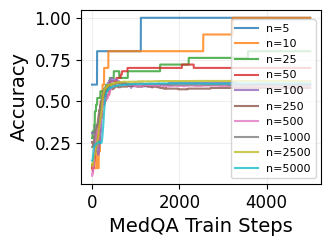

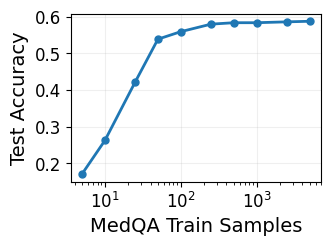

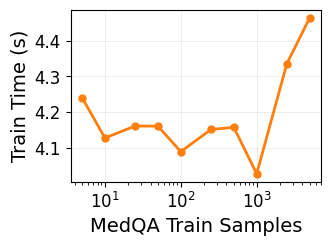

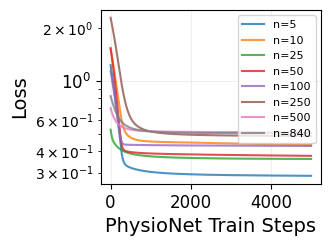

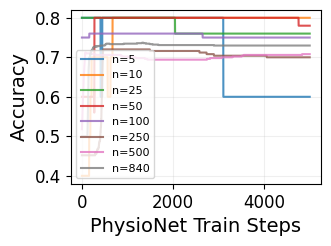

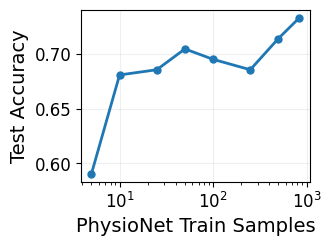

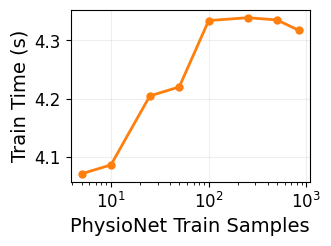

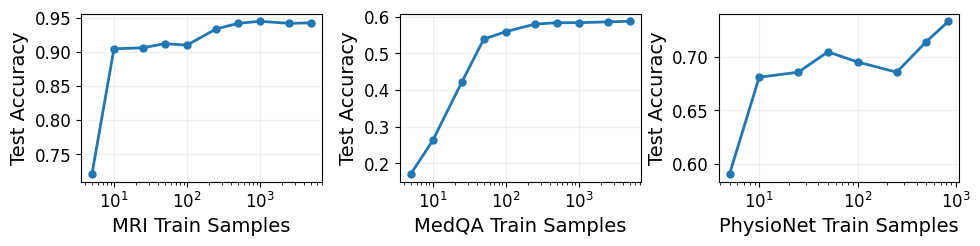

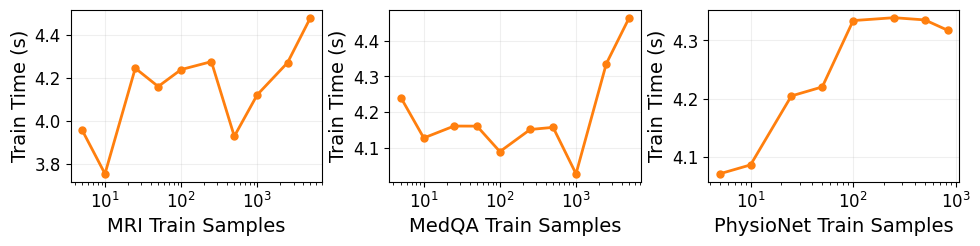


✅ All plots saved to /ssd1/ayx98/MCal/experiments/results/


In [9]:
# Plot all training curves
output_dir = mcal_root / 'experiments' / 'results'
output_dir.mkdir(exist_ok=True, parents=True)

# Map dataset names for display
dataset_display_names = {
    'mri': 'MRI',
    'medqa': 'MedQA',
    'physionet': 'PhysioNet'
}

for dataset_name, dataset_results in results.items():
    display_name = dataset_display_names.get(dataset_name, dataset_name.upper())
    
    # Loss curves (training dynamics over steps) — only if loss data exists
    if 'loss' in list(dataset_results.values())[0]:
        fig = plot_training_curves(dataset_results, display_name, metric='loss')
        plt.savefig(output_dir / f'{dataset_name}_loss_curves.pdf', dpi=300, bbox_inches='tight')
        plt.show()

        # Accuracy curves (training dynamics over steps)
        fig = plot_training_curves(dataset_results, display_name, metric='acc')
        plt.savefig(output_dir / f'{dataset_name}_acc_curves.pdf', dpi=300, bbox_inches='tight')
        plt.show()

    # Test accuracy vs sample size (individual plot per dataset)
    sample_sizes_list = sorted(dataset_results.keys())
    test_accs = [dataset_results[n]['test_acc'] for n in sample_sizes_list]

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.plot(sample_sizes_list, test_accs, 'o-', linewidth=LINEWIDTH, markersize=5)
    ax.set_xlabel(f'{display_name} Train Samples', fontsize=LABEL_FONTSIZE)
    ax.set_ylabel('Test Accuracy', fontsize=LABEL_FONTSIZE)
    ax.tick_params(axis='both', which='major', labelsize=TICK_LABELSIZE)
    ax.grid(alpha=GRID_ALPHA)
    ax.set_xscale('log')
    plt.tight_layout(pad=TIGHT_PAD)
    plt.savefig(output_dir / f'{dataset_name}_test_acc_vs_n.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Training time vs sample size (individual plot per dataset)
    training_times = [dataset_results[n]['training_time'] for n in sample_sizes_list]
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.plot(sample_sizes_list, training_times, 'o-', linewidth=LINEWIDTH, markersize=5, color='C1')
    ax.set_xlabel(f'{display_name} Train Samples', fontsize=LABEL_FONTSIZE)
    ax.set_ylabel('Train Time (s)', fontsize=LABEL_FONTSIZE)
    ax.tick_params(axis='both', which='major', labelsize=TICK_LABELSIZE)
    ax.grid(alpha=GRID_ALPHA)
    ax.set_xscale('log')
    plt.tight_layout(pad=TIGHT_PAD)
    plt.savefig(output_dir / f'{dataset_name}_training_time_vs_n.pdf', dpi=300, bbox_inches='tight')
    plt.show()

# Plot test accuracy vs sample size (combined plot)
fig, axes = plt.subplots(1, 3, figsize=(3 * fig_width, fig_height))

for idx, (dataset_name, dataset_results) in enumerate(results.items()):
    ax = axes[idx]
    display_name = dataset_display_names.get(dataset_name, dataset_name.upper())

    sample_sizes_list = sorted(dataset_results.keys())
    test_accs = [dataset_results[n]['test_acc'] for n in sample_sizes_list]

    ax.plot(sample_sizes_list, test_accs, 'o-', linewidth=LINEWIDTH, markersize=5)
    ax.set_xlabel(f'{display_name} Train Samples', fontsize=LABEL_FONTSIZE)
    ax.set_ylabel('Test Accuracy', fontsize=LABEL_FONTSIZE)
    ax.tick_params(axis='both', which='major', labelsize=TICK_LABELSIZE)
    ax.grid(alpha=GRID_ALPHA)
    ax.set_xscale('log')

plt.tight_layout(pad=TIGHT_PAD)
plt.savefig(output_dir / 'test_accuracy_vs_sample_size_combined.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot training time vs sample size (combined plot)
fig, axes = plt.subplots(1, 3, figsize=(3 * fig_width, fig_height))

for idx, (dataset_name, dataset_results) in enumerate(results.items()):
    ax = axes[idx]
    display_name = dataset_display_names.get(dataset_name, dataset_name.upper())

    sample_sizes_list = sorted(dataset_results.keys())
    training_times = [dataset_results[n]['training_time'] for n in sample_sizes_list]

    ax.plot(sample_sizes_list, training_times, 'o-', linewidth=LINEWIDTH, markersize=5, color='C1')
    ax.set_xlabel(f'{display_name} Train Samples', fontsize=LABEL_FONTSIZE)
    ax.set_ylabel('Train Time (s)', fontsize=LABEL_FONTSIZE)
    ax.tick_params(axis='both', which='major', labelsize=TICK_LABELSIZE)
    ax.grid(alpha=GRID_ALPHA)
    ax.set_xscale('log')

plt.tight_layout(pad=TIGHT_PAD)
plt.savefig(output_dir / 'training_time_vs_sample_size_combined.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ All plots saved to {output_dir}/")


MISSINGNESS BIAS PLOTS


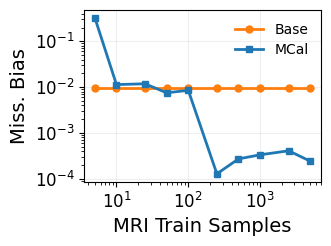


MRI:
  Average bias reduction: -278.1%
  Bias at n=5: Uncal=0.0098, Cal=0.3282
  Bias at n=5000: Uncal=0.0098, Cal=0.0002


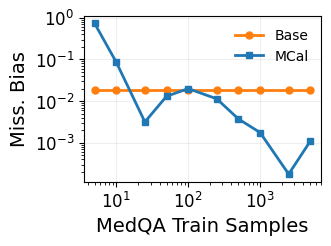


MedQA:
  Average bias reduction: -363.5%
  Bias at n=5: Uncal=0.0188, Cal=0.7295
  Bias at n=5000: Uncal=0.0188, Cal=0.0011


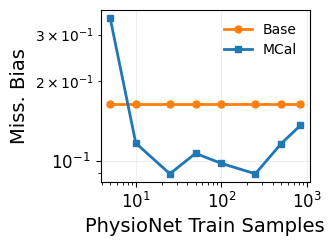


PhysioNet:
  Average bias reduction: 16.0%
  Bias at n=5: Uncal=0.1635, Cal=0.3475
  Bias at n=840: Uncal=0.1635, Cal=0.1359


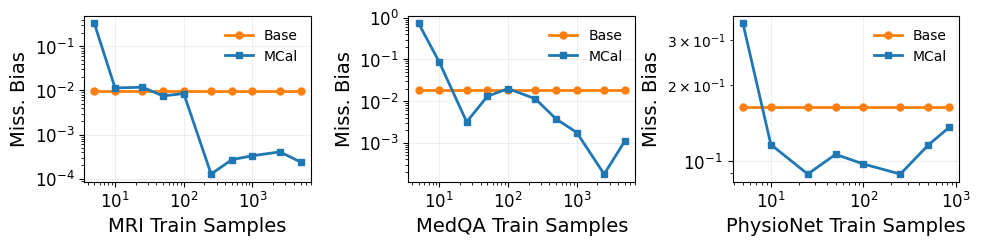


✅ Missingness bias plots saved


In [10]:
# Missingness bias plots
print("\n" + "="*60)
print("MISSINGNESS BIAS PLOTS")
print("="*60)

# Individual missingness bias plots for each dataset
for dataset_name, dataset_results in results.items():
    display_name = dataset_display_names.get(dataset_name, dataset_name.upper())
    
    sample_sizes_list = sorted(dataset_results.keys())
    bias_uncal = [dataset_results[n]['missingness_bias_uncal'] for n in sample_sizes_list]
    bias_cal = [dataset_results[n]['missingness_bias_cal'] for n in sample_sizes_list]
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.plot(sample_sizes_list, bias_uncal, 'o-', linewidth=LINEWIDTH, markersize=5, 
            color='#ff7f0e', label='Base')
    ax.plot(sample_sizes_list, bias_cal, 's-', linewidth=LINEWIDTH, markersize=5, 
            color='#1f77b4', label='MCal')
    ax.set_xlabel(f'{display_name} Train Samples', fontsize=LABEL_FONTSIZE)
    ax.set_ylabel('Miss. Bias', fontsize=LABEL_FONTSIZE)
    ax.legend(fontsize=LEGEND_FONTSIZE, loc='best', frameon=False)
    ax.tick_params(axis='both', which='major', labelsize=TICK_LABELSIZE)
    ax.grid(alpha=GRID_ALPHA)
    ax.set_xscale('log')
    ax.set_yscale('log')
    plt.tight_layout(pad=TIGHT_PAD)
    plt.savefig(output_dir / f'{dataset_name}_missingness_bias_vs_n.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print summary statistics
    avg_reduction = np.mean([dataset_results[n]['missingness_bias_reduction'] for n in sample_sizes_list])
    print(f"\n{display_name}:")
    print(f"  Average bias reduction: {avg_reduction:.1f}%")
    print(f"  Bias at n={min(sample_sizes_list)}: Uncal={bias_uncal[0]:.4f}, Cal={bias_cal[0]:.4f}")
    print(f"  Bias at n={max(sample_sizes_list)}: Uncal={bias_uncal[-1]:.4f}, Cal={bias_cal[-1]:.4f}")

# Combined missingness bias plot
fig, axes = plt.subplots(1, 3, figsize=(3 * fig_width, fig_height))

for idx, (dataset_name, dataset_results) in enumerate(results.items()):
    ax = axes[idx]
    display_name = dataset_display_names.get(dataset_name, dataset_name.upper())

    sample_sizes_list = sorted(dataset_results.keys())
    bias_uncal = [dataset_results[n]['missingness_bias_uncal'] for n in sample_sizes_list]
    bias_cal = [dataset_results[n]['missingness_bias_cal'] for n in sample_sizes_list]

    ax.plot(sample_sizes_list, bias_uncal, 'o-', linewidth=LINEWIDTH, markersize=5, 
            color='#ff7f0e', label='Base')
    ax.plot(sample_sizes_list, bias_cal, 's-', linewidth=LINEWIDTH, markersize=5, 
            color='#1f77b4', label='MCal')
    ax.set_xlabel(f'{display_name} Train Samples', fontsize=LABEL_FONTSIZE)
    ax.set_ylabel('Miss. Bias', fontsize=LABEL_FONTSIZE)
    ax.legend(fontsize=LEGEND_FONTSIZE, loc='best', frameon=False)
    ax.tick_params(axis='both', which='major', labelsize=TICK_LABELSIZE)
    ax.grid(alpha=GRID_ALPHA)
    ax.set_xscale('log')
    ax.set_yscale('log')

plt.tight_layout(pad=TIGHT_PAD)
plt.savefig(output_dir / 'missingness_bias_vs_sample_size_combined.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Missingness bias plots saved")

In [11]:
# Save results
results_file = mcal_root / 'results' / 'mcal_training_dynamics.json'
with open(results_file, 'w') as f:
    json.dump(results, f, indent=2)
print(f"Results saved to: {results_file}")

Results saved to: /ssd1/ayx98/MCal/results/mcal_training_dynamics.json
